# [LAB-09] 7. [PBT] 선형회귀 파이프라인

## EDA 결과

| 채택여부 | 변수 | 검정방법 | 유의수준 (p) | 효과크기 | 비대칭신호 | 공선성 신호 | 근거 |
|---|---|---|---|---|---|---|---|
| ✅ 채택 | `carat` | Spearman | $< 0.05$ | ρ=+0.963 (강함) | 우편향 / log1p 필요 | **O** (x 0.996 / y 0.996 / z 0.993) | 단독 설명력 최상위(동률) + **크기 축 대표** → 1순위 |
| ✅ 채택 | `color` | Welch ANOVA | $< 0.05$ | np2=0.031 (Small) | 해당 없음 | **X** | 집단 차이 유의, `carat` 통제 시 순효과 기대 |
| ✅ 채택 | `clarity` | Welch ANOVA | $< 0.05$ | np2=0.027 (Small) | 해당 없음 | **X** | 집단 차이 유의 + **`carat` 기울기 2.76배 차** |
| ✅ 채택 | `cut` | Welch ANOVA | $< 0.05$ | np2=0.013 (Small) | 해당 없음 | **X** | 집단 차이 유의 (효과크기 최소) |
| 🟡 후보 | `x` | Spearman | $< 0.05$ | ρ=+0.963 (강함) | 대칭 / 불필요 | **O** (y 0.998 / carat 0.996) | 설명력은 최상급이나 **크기 축 대표를 `carat`에 양보** → VIF 결과에 따라 대체 투입 |
| 🟡 후보 | `y` | Spearman | $< 0.05$ | ρ=+0.963 (강함) | 우편향 / log1p 필요 | **O** (x 0.998 / carat 0.996) | 설명력은 최상급이나 대표 양보. 단 **58.9mm 오류값 정제 선행 필요** |
| 🟡 후보 | `z` | Spearman | $< 0.05$ | ρ=+0.957 (강함) | 우편향 / log1p 필요 | **O** (carat 0.993 / x 0.987) | 설명력은 최상급이나 대표 양보. 단 **31.8mm 오류값 정제 선행 필요** |
| 🟡 후보 | `table` | Spearman | $< 0.05$ | ρ=+0.171 (약함) | 경미한 우편향 / 변환 선택적 | **X** (최대 -0.245) | 관계는 약하나(\|ρ\|<0.3) **중복이 없어** 정보 가치 존재 → 계수 유의성으로 최종 판정 |
| ❌ 제외 | `depth` | Spearman | 0.018 | ρ=+0.010 (약함) | 대칭 / 불필요 | **X** | **효과 사실상 0** — n=53,794 대표본 탓에 유의만 떴을 뿐, ρ≈0으로 단조 관계 자체가 없음 → **공선성과 무관하게 설명력 부재** |


## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *
from IPython.display import display, Markdown

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 품질 점검 완료 데이터 셋 가져오기

- **LAB-05**에서 저장해 둔 데이터 셋과 기술통계량을 한번에 로드한다.

In [2]:
origin = load_data("diamonds_qtcheck")
num_desc = load_data("diamonds_numerical_summary")
cat_desc = load_data("diamonds_categorical_summary")

📚 다이아몬드 데이터셋의 품질 검사 완료 버전 (출처: 자체 정제)

    field    description
--  -------  -------------------------------------------------------------------
 0  price    다이아몬드 가격 (USD, $326 ~ $18,823)
 1  carat    중량 (0.2~5.01)
 2  cut      컷 품질 (Fair, Good, Very Good, Premium, Ideal)
 3  color    색상 등급 - J (worst) to D (best)
 4  clarity  투명도 등급 (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
 5  x        길이 mm (0~10.74)
 6  y        너비 mm (0--58.9)
 7  z        두께 mm (0--31.8)
 8  depth    비율 정보 = z / mean(x, y) = 2 * z / (x + y) (43--79)
 9  table    다이아몬드의 가장 넓은 지점에 비해 상단(테이블)의 너비 (43--95)

📚 다이아몬드 데이터셋의 연속형 변수에 대한 기술 통계량 (출처: 자체 작업)
📚 다이아몬드 데이터셋의 범주형 변수에 대한 기술 통계량 (출처: 자체 작업)


### 3. EDA 결과 반영

In [3]:
# 제외 대상 컬럼 제거
df_eda = origin.drop(columns=["depth"])

# 기술 통계량에서 제외 대상 컬럼 제거
num_desc_eda = num_desc.drop(index="depth")

# 범주형은 변경사항이 없으므로 그대로 복사
cat_desc_eda = cat_desc.copy()

### 4. 타입 변환 (명목형 확정)

- 명목형 기술통계량 표의 컬럼명이 명목형 변수 목록이다.

In [4]:
df = my_qtcheck.set_type(df_eda, as_category=cat_desc_eda.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53794 entries, 0 to 53793
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   price    53794 non-null  int64   
 1   carat    53794 non-null  float64 
 2   cut      53794 non-null  category
 3   color    53794 non-null  category
 4   clarity  53794 non-null  category
 5   x        53794 non-null  float64 
 6   y        53794 non-null  float64 
 7   z        53794 non-null  float64 
 8   table    53794 non-null  float64 
dtypes: category(3), float64(5), int64(1)
memory usage: 2.6 MB


### 5. 변수 유형 분류

In [5]:
# 종속변수
target = "price"
# 종속변수 연속형 여부
target_is_continuous = True

# 명목형 변수
nominal_cols = my_qtcheck.get_categorical_column_names(df)
# 연속형 변수
continuous_cols = my_qtcheck.get_number_column_names(df)

if target_is_continuous:
    # 연속형 변수 이름에서 종속변수 항목 제거
    continuous_cols.remove(target)
else:
    # 명목형 변수 이름에서 종속변수 항목 제거
    nominal_cols.remove(target)

print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("명목형   :", nominal_cols)
print("연속형   :", continuous_cols)

종속변수 : price
종속변수 유형: 연속형
명목형   : ['cut', 'color', 'clarity']
연속형   : ['carat', 'x', 'y', 'z', 'table']


### 6. 컬럼 의미를 정리한 딕셔너리

In [6]:
column_means = {
    "price":    "다이아몬드 가격 (USD)", 
    "carat":    "중량",
    "cut":      "컷팅 등급",    # Fair, Good, Very Good, Premium, Ideal
    "color":    "색상 등급",    # J (worst) to D (best)
    "clarity":  "투명도 등급",  # (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
    "x":        "길이(mm)",
    "y":        "너비(mm)",
    "z":        "두께(mm)",
    "table":    "테이블 너비"
}

### 7. 서열척도 적용 (필요에 따라 수행)

In [7]:
# 서열척도를 적용할 변수와 순서를 정의한다. (낮은 등급 → 높은 등급)
# -> 도메인 지식이 필요한 부분이므로 #01(준비작업)에서만 수정한다.
# -> 서열척도 대상이 없는 데이터셋이라면 제외하면 된다
ordinal_map = {
    "cut":     ["Fair", "Good", "Very Good", "Premium", "Ideal"],
    "color":   ["J", "I", "H", "G", "F", "E", "D"],
    "clarity": ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"],
}

# 정의된 내용에 따라 순서를 재지정한다.
# -> 데이터셋에 없는 컬럼은 건너뛰므로 다른 데이터셋에서도 오류가 나지 않는다.
for col, order in ordinal_map.items():
    if col in df.columns:
        df[col] = df[col].cat.reorder_categories(order, ordered=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53794 entries, 0 to 53793
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   price    53794 non-null  int64   
 1   carat    53794 non-null  float64 
 2   cut      53794 non-null  category
 3   color    53794 non-null  category
 4   clarity  53794 non-null  category
 5   x        53794 non-null  float64 
 6   y        53794 non-null  float64 
 7   z        53794 non-null  float64 
 8   table    53794 non-null  float64 
dtypes: category(3), float64(5), int64(1)
memory usage: 2.6 MB


## #02. 선형회귀 파이프라인

### 1. 전처리 체크포인트 정의

- 전처리 단계를 하나씩 누적한 체크포인트 (아래로 갈수록 전처리가 하나 더 붙는다)
- labeling, encode 는 기본값이 True 이므로 따로 적지 않는다

In [8]:
checkpoints = {
    "0_기준선":    dict(),
    "1_로그변환":   dict(log=True),
    "2_이상치대체": dict(log=True, outlier=True),
    "3_공선성제거": dict(log=True, outlier=True, vif=True),
    "4_스케일링":   dict(log=True, outlier=True, vif=True, scale=True),
}

### 2. 더미변수의 기준 확인

- `labeling` 은 명목형의 값을 **알파벳 순서**로 0부터 매긴다.
- 이어지는 `encode`(더미 인코딩)가 이 정수를 컬럼명에 사용하므로, 회귀계수를 해석하려면 매핑을 알아야 한다.
  - 예) `cut_2` 는 `cut = Ideal` 을 의미한다.
- `drop_first=True` 로 **0번 범주가 기준** 이 되어 빠진다. 더미 계수는 모두 이 기준 범주 대비 차이다.

In [9]:
# 라벨 매핑만 확인하는 용도 (반환값은 사용하지 않는다)
_ = my_prep.labeling(df, columns=nominal_cols)

cut (5종): Fair=0, Good=1, Ideal=2, Premium=3, Very Good=4
color (7종): D=0, E=1, F=2, G=3, H=4, I=5, J=6
clarity (8종): I1=0, IF=1, SI1=2, SI2=3, VS1=4, VS2=5, VVS1=6, VVS2=7


### 3. 체크포인트별 모델 적합

- `fit_pipeline` 은 전처리부터 모델 적합까지 한 번에 수행하고, 계수 해석에 필요한 변환 정보를 결과 객체에 붙여 돌려준다.
- `backward=True`(기본값)이므로 유의하지 않은 독립변수는 후진소거법으로 하나씩 제거된다.

In [10]:
fits = {}

for name in checkpoints:
    print(f"\n▶︎ --- {name} ---")

    # 전처리 + 모델 적합을 한 번에 수행한다.
    # -> name 을 지정해 두면 compare_models 의 결과표에 그대로 사용된다.
    fits[name] = my_ols.fit_pipeline(df, target, nominal_cols=nominal_cols, name=name, verbose=False, **checkpoints[name])


▶︎ --- 0_기준선 ---

유의하지 않은 독립변수 제거 → y (p = 0.7865)
유의하지 않은 독립변수 제거 → z (p = 0.4474)

▶︎ --- 1_로그변환 ---

유의하지 않은 독립변수 제거 → table (p = 0.7514)

▶︎ --- 2_이상치대체 ---

유의하지 않은 독립변수 제거 → table (p = 0.5136)

▶︎ --- 3_공선성제거 ---

완료! 남은 변수: ['table', 'z']
최대 VIF = 1.03


▶︎ --- 4_스케일링 ---

완료! 남은 변수: ['table', 'z']
최대 VIF = 1.03



### 4. 성능 비교와 최종 모델 선택

- 종속변수에 로그가 적용된 모델은 예측값을 **원본 척도(달러)로 되돌려** RMSE·MAE·R²(원본척도)를 계산한다.
  - 척도가 다른 지표(`R2(모델척도)`·`AIC`·`BIC`)는 체크포인트 간 비교에 쓸 수 없다.
- 1위와의 격차가 5% 이내면 **근소 격차 그룹**으로 묶어 변수가 더 적은(간명한) 모델을 우선한다.

In [11]:
# 성능표를 출력하고 가장 좋은 모델을 반환받는다
final_fit = my_ols.compare_models(fits)

print("최종 모델 :", final_fit.name_)
print("독립변수  :", int(final_fit.df_model), "개")

,변수수,R2(모델척도),Adj.R2,AIC,BIC,R2(원본척도),RMSE,MAE,Gap(%)
모델,,,,,,,,,
2_이상치대체,21,0.983,0.983,-64286.219,-64090.575,0.957,831.952,406.251,0.000
1_로그변환,21,0.983,0.983,-64194.658,-63999.014,0.957,832.090,405.550,0.020
3_공선성제거,19,0.968,0.968,-30419.977,-30242.119,0.924,1096.543,475.759,31.800
4_스케일링,19,0.968,0.968,-30419.977,-30242.119,0.924,1096.543,475.759,31.800
0_기준선,20,0.919,0.919,909186.897,909373.649,0.919,1131.507,743.546,36.010


최종 모델 : 2_이상치대체
독립변수  : 21 개


#### 💡 인사이트

- **로그변환 + 이상치 대체**가 가장 효과적 — 기준선 RMSE 1,131.507에서 → 832.079 (−35.99%)
- **공선성 제거**는 에러율(RMSE)이 증가하여 **오히려 손해** — 1,095.78 (+31.7%). carat·x·y를 걷어내고 z(두께)를 크기 축 대표로 남겼지만, 가격을 결정하는 것은 중량이다
- **정규화**는 성능 불변 — 4_스케일링은 3과 지표가 완전히 동일(계수 척도만 변화)
- **채택은 2_이상치대체 — 단, 변수가 21개로 가장 많다**

## #03. 도메인 지식 반영 모델 전처리

### 1. 데이터 전처리

- 기계적으로 채택된 x를 사용하지 않고 일반적으로 다이아몬드의 가격 결정에 많은 영향을 준다고 알려져 있는 carat을 투입한다.
- carat과 상관관계가 높은 x, y, z는 제거한다.

In [12]:
df2 = df.drop(columns=["x", "y", "z"])
df2.head()

,price,carat,cut,color,clarity,table
0,326,0.230,Ideal,E,SI2,55.000
1,326,0.210,Premium,E,SI1,61.000
2,327,0.230,Good,E,VS1,65.000
3,334,0.290,Premium,I,VS2,58.000
4,335,0.310,Good,J,SI2,58.000


### 2. 도메인 지식 전처리 버전에 대한 체크포인트 정의

- `df2` 는 크기 축 대표로 `carat` 만 남기고 `x`·`y`·`z` 를 **도메인 지식으로 직접 제거**한 버전
  - `4_스케일링` 에서 정규화가 예측 성능을 바꾸지 않는 것을 이미 확인했으므로 도메인 쪽에서는 생략한다.

In [13]:
# 도메인 지식을 반영한 데이터(df2)에 적용할 체크포인트
# -> 앞의 checkpoints 와 전처리 조합을 동일하게 맞춘다
domain_checkpoints = {
    "5_도메인_기준선":    dict(),
    "6_도메인_로그변환":   dict(log=True),
    "7_도메인_이상치대체": dict(log=True, outlier=True),
    "8_도메인_공선성제거": dict(log=True, outlier=True, vif=True),
}

### 3. 모델 적합 (`fits` 에 누적)

- 앞에서 만든 `fits` 딕셔너리에 **이어서 담아야** 두 방식을 한 표에서 비교할 수 있다.

In [14]:
for name in domain_checkpoints:
    print(f"\n▶︎ --- {name} ---")

    # 데이터만 df2 로 바꾸고 나머지는 동일하게 적합한다.
    # -> fits 에 누적하므로 앞의 5개 모델과 함께 비교된다.
    fits[name] = my_ols.fit_pipeline(df2, target, nominal_cols=nominal_cols, name=name, verbose=False, **domain_checkpoints[name])

print("\n누적된 모델 :", len(fits), "개")


▶︎ --- 5_도메인_기준선 ---


▶︎ --- 6_도메인_로그변환 ---

유의하지 않은 독립변수 제거 → table (p = 0.9194)

▶︎ --- 7_도메인_이상치대체 ---

유의하지 않은 독립변수 제거 → table (p = 0.9575)

▶︎ --- 8_도메인_공선성제거 ---

완료! 남은 변수: ['carat', 'table']
최대 VIF = 1.04

유의하지 않은 독립변수 제거 → table (p = 0.9575)

누적된 모델 : 9 개


### 4. 전체 모델 성능 비교

In [15]:
# 9개 모델을 한 번에 비교한다
final_fit = my_ols.compare_models(fits)

print("최종 모델 :", final_fit.name_)
print("독립변수  :", int(final_fit.df_model), "개")

,변수수,R2(모델척도),Adj.R2,AIC,BIC,R2(원본척도),RMSE,MAE,Gap(%)
모델,,,,,,,,,
7_도메인_이상치대체,18,0.983,0.983,-63903.108,-63734.143,0.960,796.879,402.916,0.000
8_도메인_공선성제거,18,0.983,0.983,-63903.108,-63734.143,0.960,796.879,402.916,0.000
6_도메인_로그변환,18,0.983,0.983,-63887.676,-63718.710,0.960,798.871,403.074,0.250
2_이상치대체,21,0.983,0.983,-64286.219,-64090.575,0.957,831.952,406.251,4.400
1_로그변환,21,0.983,0.983,-64194.658,-63999.014,0.957,832.090,405.550,4.420
3_공선성제거,19,0.968,0.968,-30419.977,-30242.119,0.924,1096.543,475.759,37.600
4_스케일링,19,0.968,0.968,-30419.977,-30242.119,0.924,1096.543,475.759,37.600
0_기준선,20,0.919,0.919,909186.897,909373.649,0.919,1131.507,743.546,41.990
5_도메인_기준선,19,0.916,0.916,911471.617,911649.475,0.916,1155.814,803.132,45.040


최종 모델 : 7_도메인_이상치대체
독립변수  : 18 개


#### 💡 인사이트 — 도메인 지식이 기계적 제거를 이겼다

**최종 모델: `7_도메인_이상치대체`** — 독립변수 18개, RMSE 796.68달러, R²(원본척도) 0.960

- 도메인 모델이 상위 3개를 독식했다. 기계적 최고 기록(832.08)보다 **RMSE는 4.4% 낮고 변수는 3개 더 적다**(18 vs 21).
- **도메인 지식만으로는 부족하다.** `5_도메인_기준선` 은 1,155.81로 9개 중 꼴찌다.
  `x`·`y`·`z` 를 걷어낸 것만으로는 정보가 줄어 손해를 보고, 로그 변환을 더한 `6` 에서 798.66으로 **31% 개선**된다.
  변수 선택과 변환은 함께 가야 한다.
- **기계적 제거의 한계는 "무엇을 남길지 모른다"는 점이다.** VIF는 넷의 상관이 동률(ρ≈0.96)이라 아무거나 남기지만,
  `z` 를 남긴 `3_공선성제거`(1,095.78)와 `carat` 을 남긴 `7`(796.68)은 **37% 차이**가 난다.
- **도메인 모델에서는 이상치 대체·공선성 제거가 할 일이 거의 없다.** `6` → `7` 개선은 0.25%에 그치고,
  `8` 은 `7` 과 완전히 같다(`carat`·`table` 최대 VIF 1.04로 제거 대상 없음). 도메인 지식으로 공선성을 미리 해소한 결과다.
- **계수 해석**: `log(carat)` 의 B = 1.883, 종속변수는 `log1p(price)` 이므로 **탄력성**이다.
  → 중량이 1% 늘면 가격은 약 **1.88% 상승**한다. 중량이 2배가 되면 가격은 `2^1.88 ≈ 3.7배` 로,
  가격이 중량에 비례하지 않고 **가파르게 체증**한다는 시장 상식과 일치한다.

## #04. 최종 채택 모델에 대한 결과 보고

### 1. 결과 보고・가정 확인 일괄 처리

## 최종 모델: 7_도메인_이상치대체

### ▶︎ 성능 보고

#### 1) 모형 적합도

**Note. n = 53794. F(18, 53775) = 169374.3, p < 0.001, R² = 0.983, Adj.R² = 0.983, Durbin-Watson = 1.253**

log(price)를 종속변수로, log(carat), cut_1, cut_2, cut_3, cut_4, color_1, color_2, color_3, color_4, color_5, color_6, clarity_1, clarity_2, clarity_3, clarity_4, clarity_5, clarity_6, clarity_7(을)를 독립변수로한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(18, 53775) = 169374.3, p < 0.001, R² = 0.983.

즉, log(carat), cut_1, cut_2, cut_3, cut_4, color_1, color_2, color_3, color_4, color_5, color_6, clarity_1, clarity_2, clarity_3, clarity_4, clarity_5, clarity_6, clarity_7는 log(price)의 약 98.27%를 설명하는 것으로 나타났다.

#### 2) 회귀계수 보고표

,종속변수,독립변수,B,표준오차,표준오차(HC3),β,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,price,carat,1.884,0.001,0.001,1.086,1669.480,1452.680,0.000,0.000,0.762,1.312
1,price,clarity_5,0.741,0.005,0.009,0.306,143.216,86.484,0.000,0.000,0.071,14.172
2,price,clarity_4,0.811,0.005,0.009,0.287,154.440,94.256,0.000,0.000,0.093,10.697
3,price,clarity_7,0.946,0.005,0.009,0.272,174.772,107.779,0.000,0.000,0.133,7.524
4,price,clarity_6,1.018,0.006,0.009,0.252,182.710,114.560,0.000,0.000,0.169,5.912
5,price,clarity_2,0.592,0.005,0.009,0.250,115.063,69.201,0.000,0.000,0.068,14.647
6,price,clarity_1,1.113,0.006,0.009,0.196,184.636,119.041,0.000,0.000,0.285,3.510
7,price,clarity_3,0.427,0.005,0.009,0.158,82.580,49.577,0.000,0.000,0.088,11.394
8,price,color_6,-0.511,0.003,0.003,-0.112,-166.369,-154.951,0.000,0.000,0.712,1.405
9,price,color_5,-0.373,0.002,0.003,-0.110,-149.555,-142.317,0.000,0.000,0.591,1.691


#### 3) 영향력 순위 시각화 (표준화 계수 β)

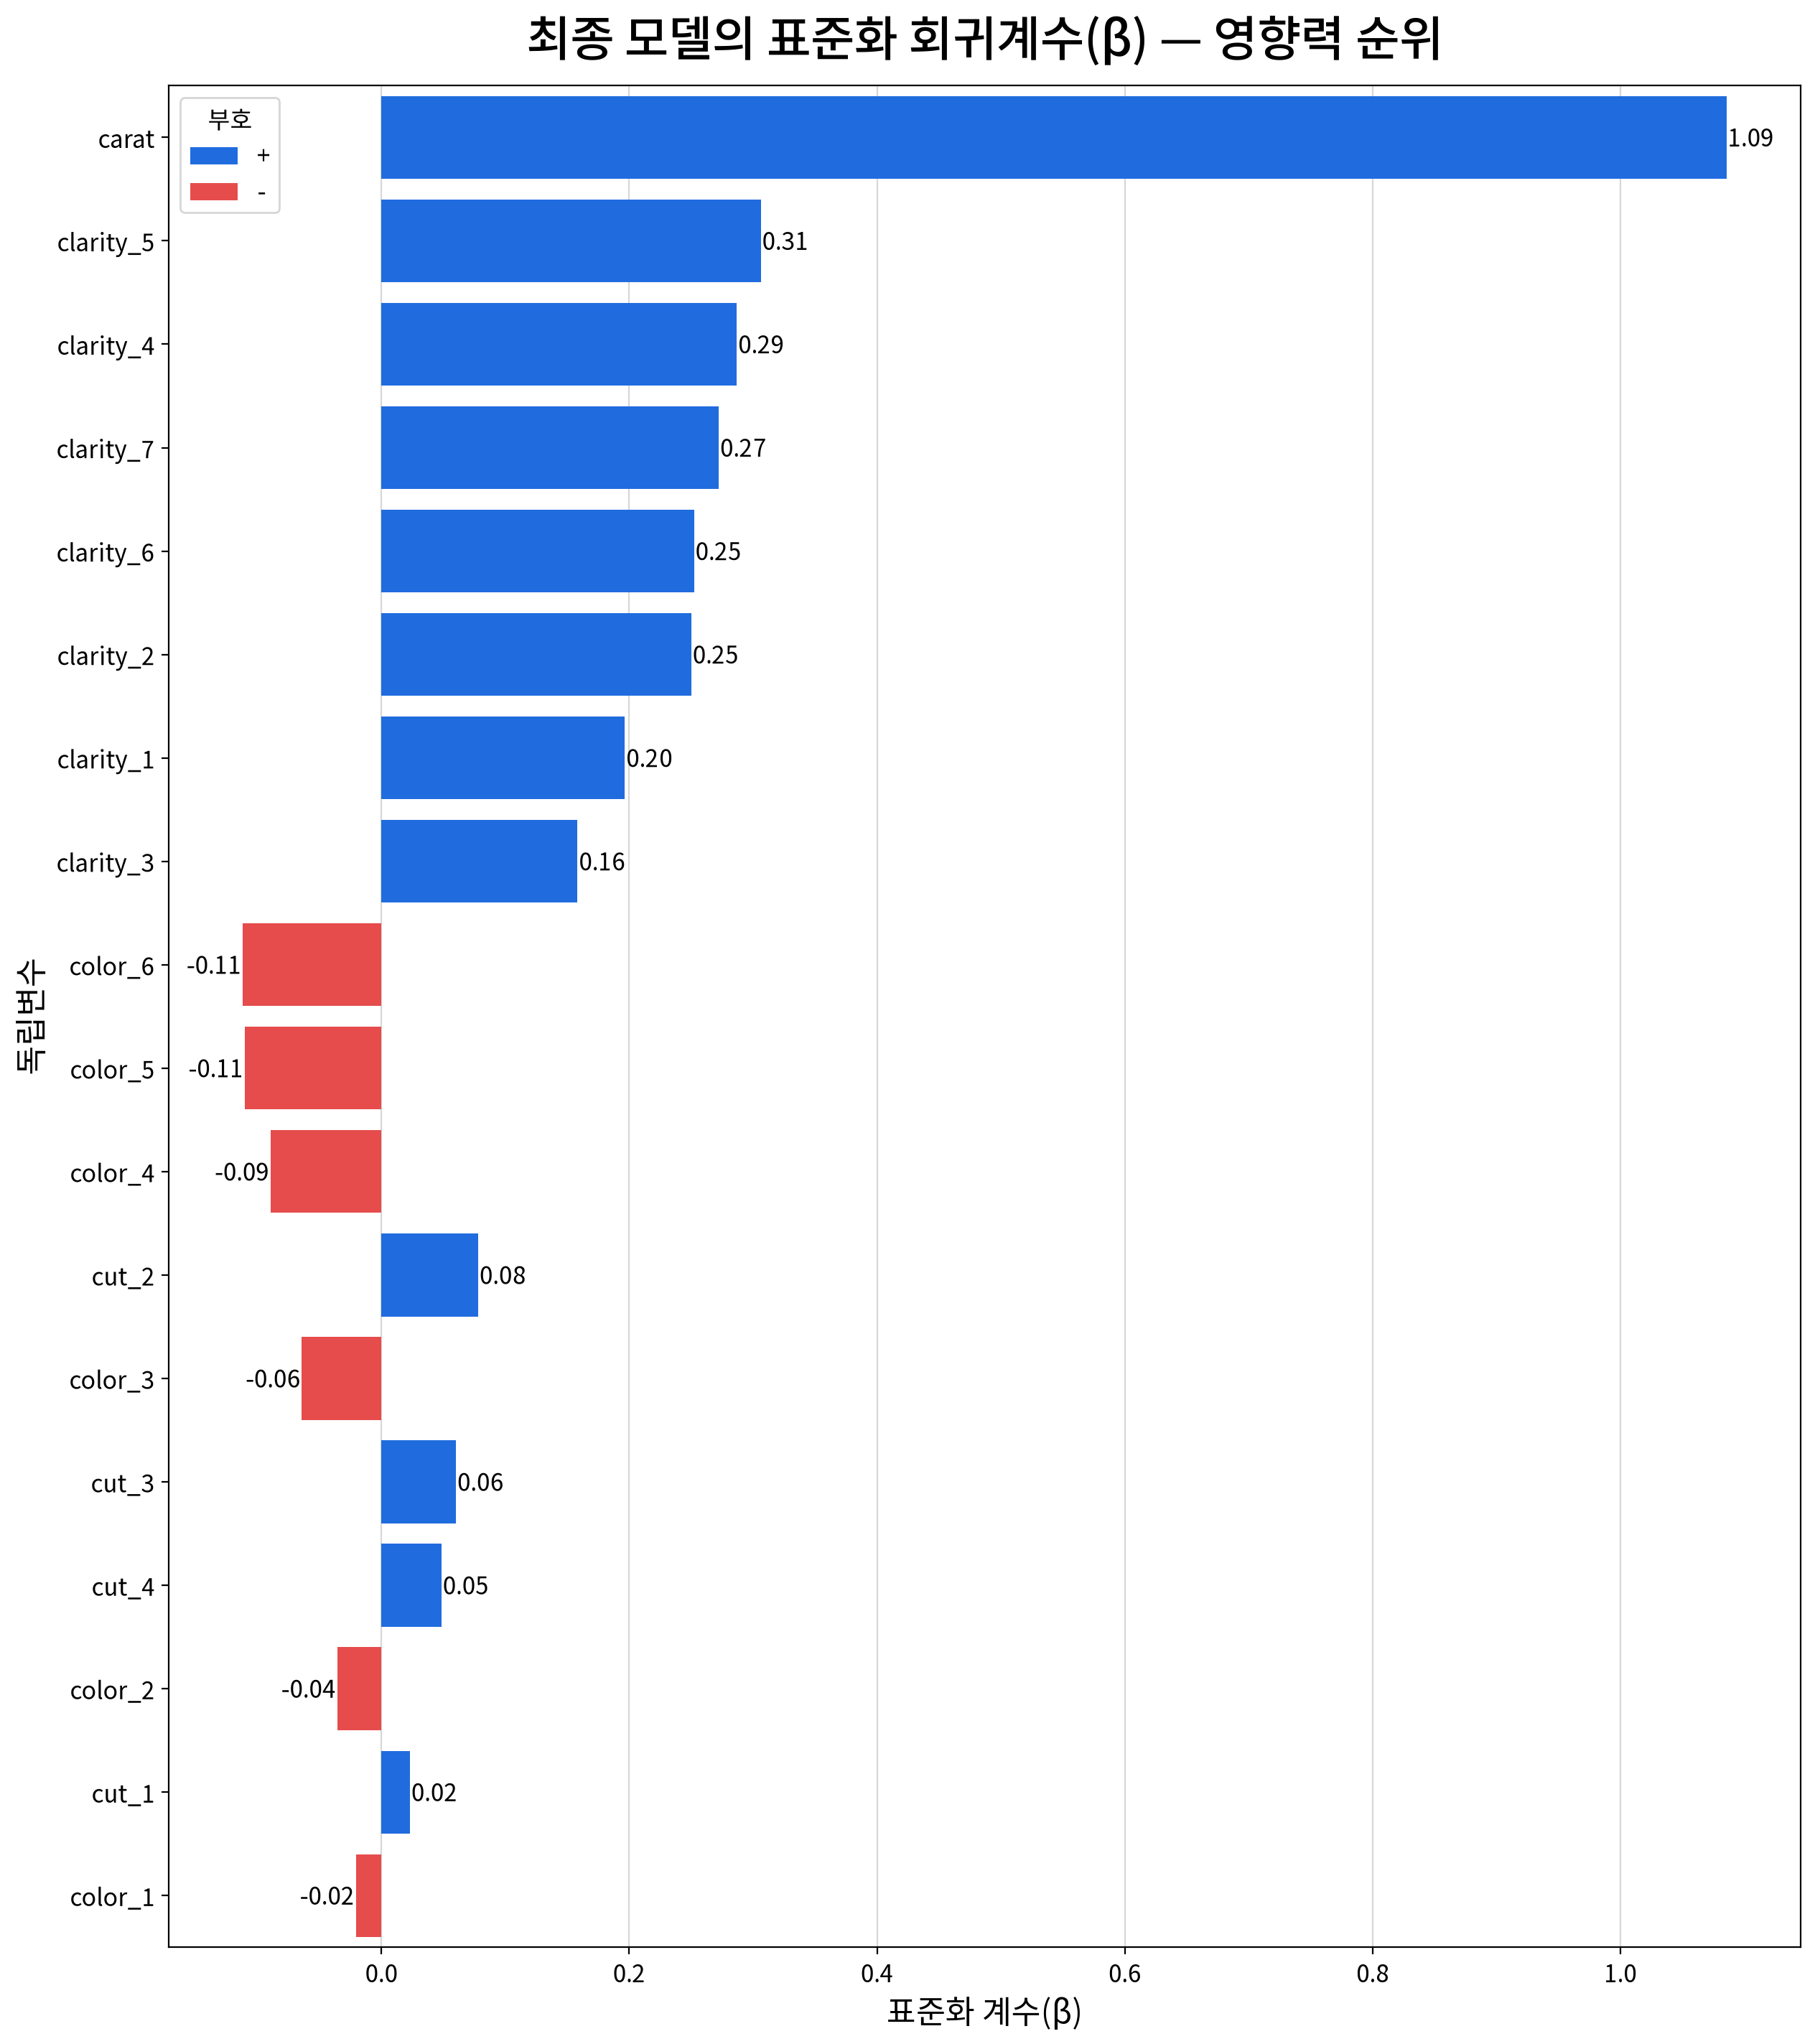

#### 4) 회귀계수 해석 문장

- **carat**의 회귀계수는 **B = 1.88**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 1452.68**, **p < .001**)      
즉, carat가 **1% 증가**할 때 price는 평균적으로 약 **1.88% 증가**하는 것으로 해석된다.
- **cut_1**의 회귀계수는 **B = 0.08**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 17.15**, **p < .001**)      
즉, cut_1가 **1 증가**할 때 price는 평균적으로 약 **8.42% 증가**하는 것으로 해석된다.
- **cut_2**의 회귀계수는 **B = 0.16**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 36.2**, **p < .001**)      
즉, cut_2가 **1 증가**할 때 price는 평균적으로 약 **17.54% 증가**하는 것으로 해석된다.
- **cut_3**의 회귀계수는 **B = 0.14**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 31.09**, **p < .001**)      
즉, cut_3가 **1 증가**할 때 price는 평균적으로 약 **15.00% 증가**하는 것으로 해석된다.
- **cut_4**의 회귀계수는 **B = 0.12**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 26.18**, **p < .001**)      
즉, cut_4가 **1 증가**할 때 price는 평균적으로 약 **12.48% 증가**하는 것으로 해석된다.
- **color_1**의 회귀계수는 **B = -0.05**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -24.01**, **p < .001**)      
즉, color_1가 **1 증가**할 때 price는 평균적으로 약 **5.26% 감소**하는 것으로 해석된다.
- **color_2**의 회귀계수는 **B = -0.09**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -41.22**, **p < .001**)      
즉, color_2가 **1 증가**할 때 price는 평균적으로 약 **9.02% 감소**하는 것으로 해석된다.
- **color_3**의 회귀계수는 **B = -0.16**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -71.62**, **p < .001**)      
즉, color_3가 **1 증가**할 때 price는 평균적으로 약 **14.81% 감소**하는 것으로 해석된다.
- **color_4**의 회귀계수는 **B = -0.25**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -107.31**, **p < .001**)      
즉, color_4가 **1 증가**할 때 price는 평균적으로 약 **22.19% 감소**하는 것으로 해석된다.
- **color_5**의 회귀계수는 **B = -0.37**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -142.32**, **p < .001**)      
즉, color_5가 **1 증가**할 때 price는 평균적으로 약 **31.10% 감소**하는 것으로 해석된다.
- **color_6**의 회귀계수는 **B = -0.51**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -154.95**, **p < .001**)      
즉, color_6가 **1 증가**할 때 price는 평균적으로 약 **40.02% 감소**하는 것으로 해석된다.
- **clarity_1**의 회귀계수는 **B = 1.11**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 119.04**, **p < .001**)      
즉, clarity_1가 **1 증가**할 때 price는 평균적으로 약 **204.24% 증가**하는 것으로 해석된다.
- **clarity_2**의 회귀계수는 **B = 0.59**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 69.2**, **p < .001**)      
즉, clarity_2가 **1 증가**할 때 price는 평균적으로 약 **80.75% 증가**하는 것으로 해석된다.
- **clarity_3**의 회귀계수는 **B = 0.43**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 49.58**, **p < .001**)      
즉, clarity_3가 **1 증가**할 때 price는 평균적으로 약 **53.31% 증가**하는 것으로 해석된다.
- **clarity_4**의 회귀계수는 **B = 0.81**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 94.26**, **p < .001**)      
즉, clarity_4가 **1 증가**할 때 price는 평균적으로 약 **125.04% 증가**하는 것으로 해석된다.
- **clarity_5**의 회귀계수는 **B = 0.74**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 86.48**, **p < .001**)      
즉, clarity_5가 **1 증가**할 때 price는 평균적으로 약 **109.78% 증가**하는 것으로 해석된다.
- **clarity_6**의 회귀계수는 **B = 1.02**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 114.56**, **p < .001**)      
즉, clarity_6가 **1 증가**할 때 price는 평균적으로 약 **176.70% 증가**하는 것으로 해석된다.
- **clarity_7**의 회귀계수는 **B = 0.95**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 107.78**, **p < .001**)      
즉, clarity_7가 **1 증가**할 때 price는 평균적으로 약 **157.58% 증가**하는 것으로 해석된다.

> ※ 위 **t**와 **유의확률**은 등분산 가정이 충족되지 않은 경우를 대비해 **HC3 로버스트 표준오차**로 계산한 값이다.     
회귀계수(B)와 효과 크기 해석은 일반 OLS와 동일하며,     
표준오차만 이분산에 강건하게 보정되어 유의성 판정이 달라질 수 있다.

---

### ▶︎ 회귀모형 가정 검정

#### 1) 선형성 검정

,statistic,p-value,linearity,result
Ramsey RESET,923.615,0.000,False,대립가설 채택 → 선형성 위배(곡선 관계 존재)


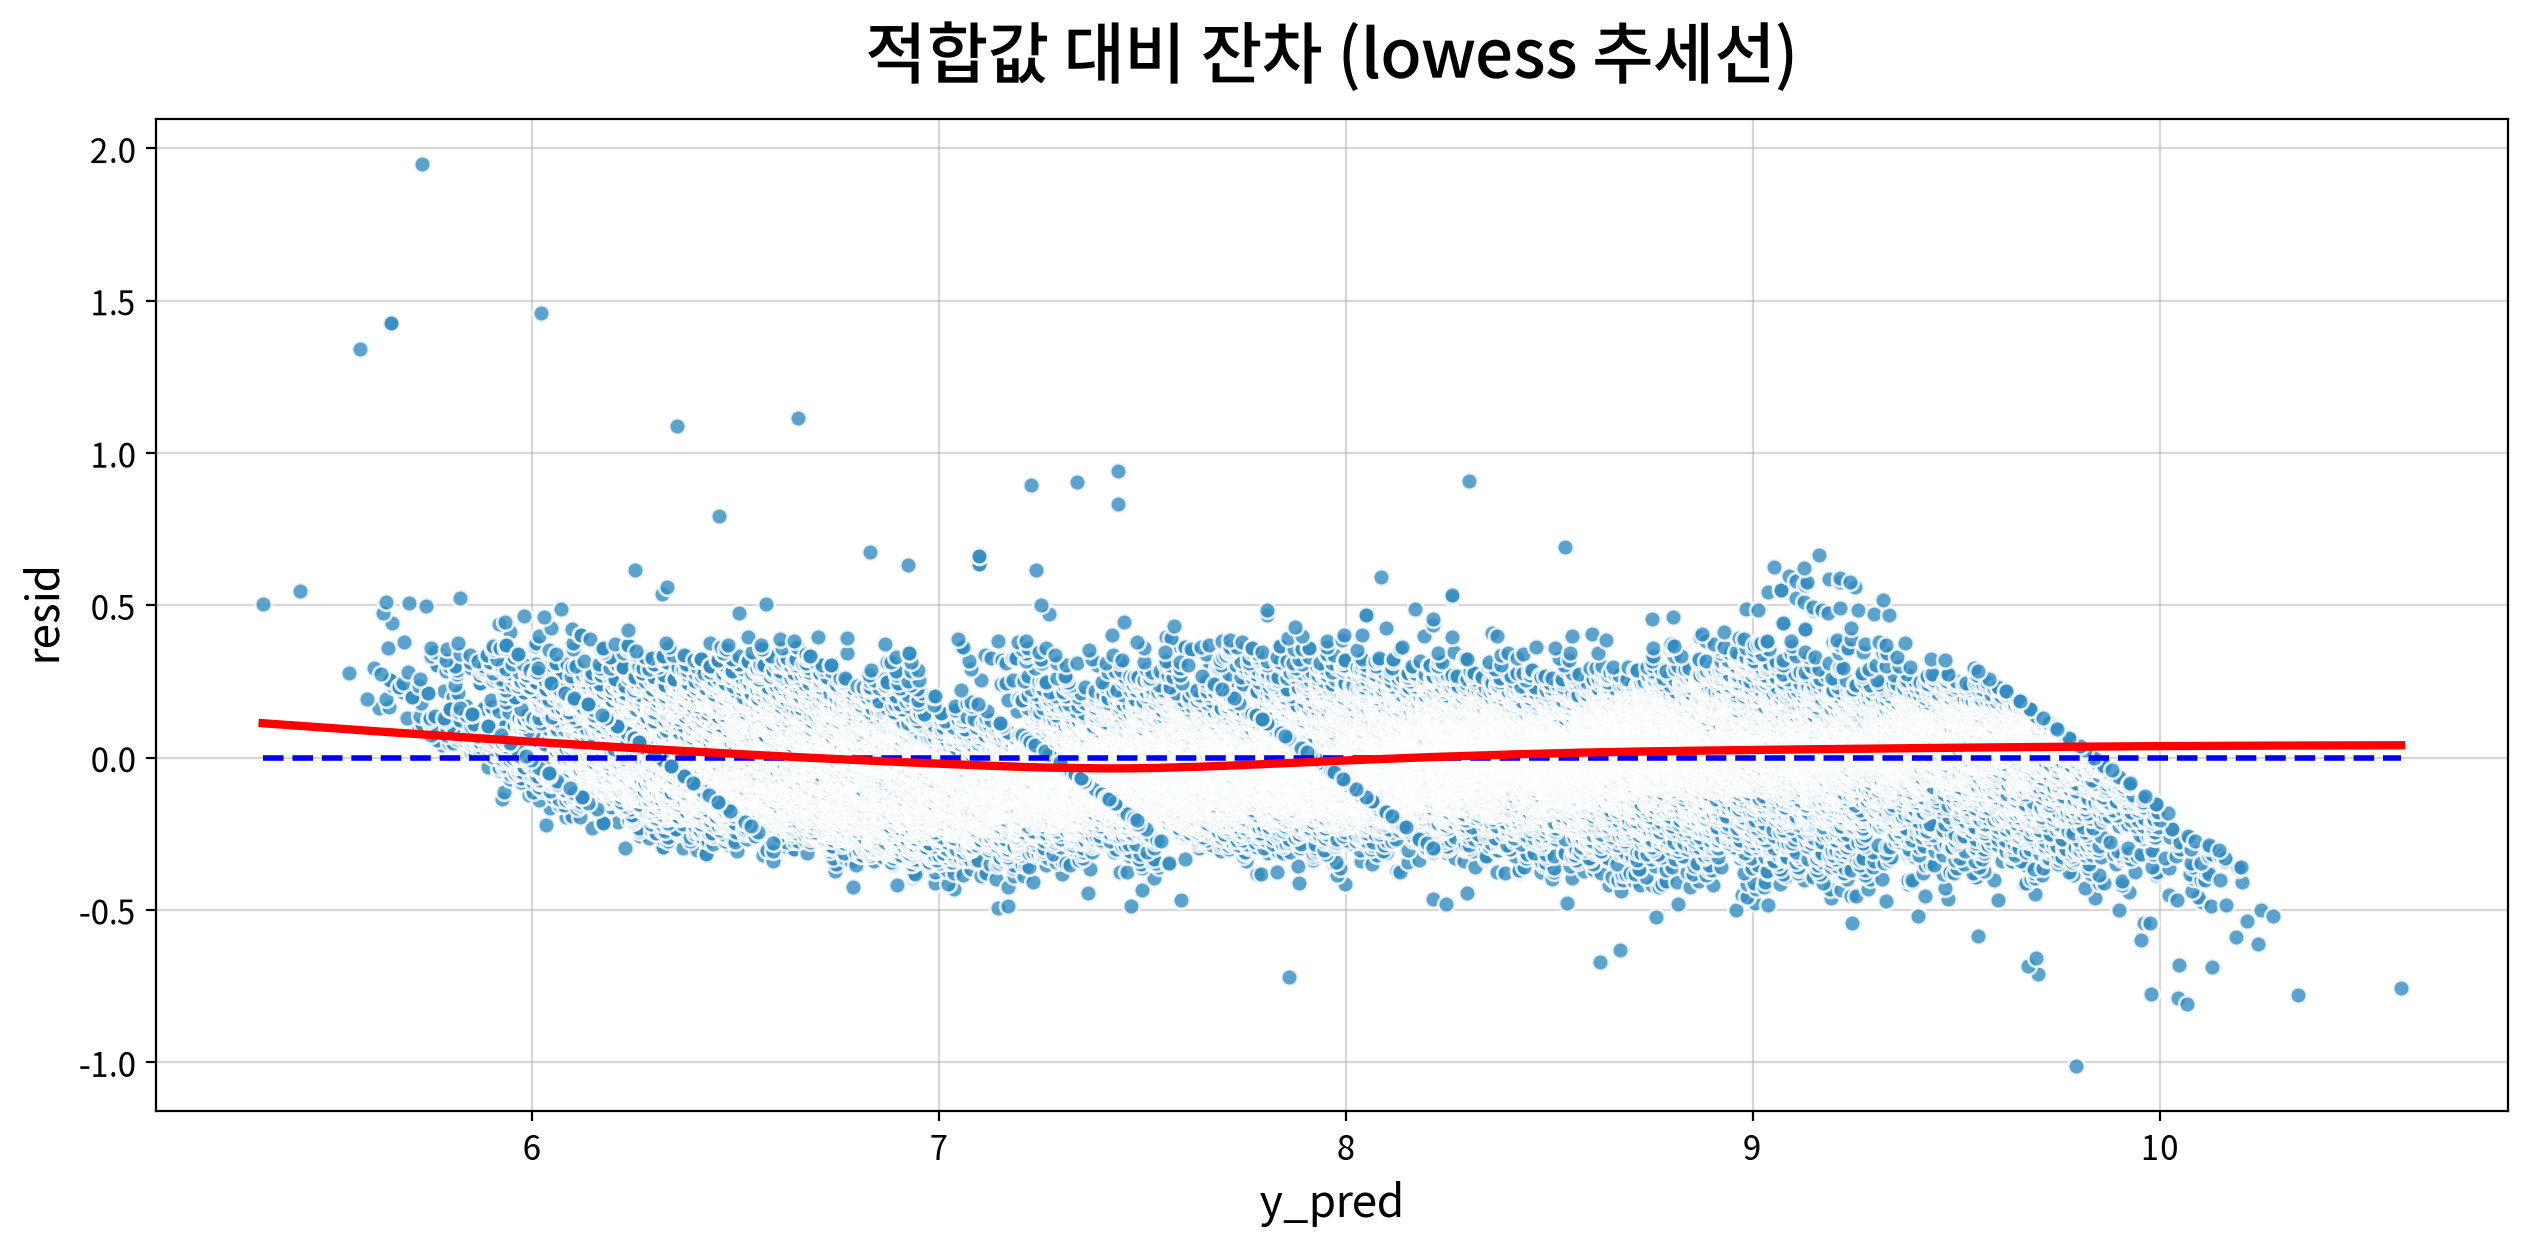

#### 2) 정규성 검정

,statistic,p-value,normality,result
Kolmogorov-Smirnov,0.018,0.000,False,대립가설 채택 → 정규성 위배


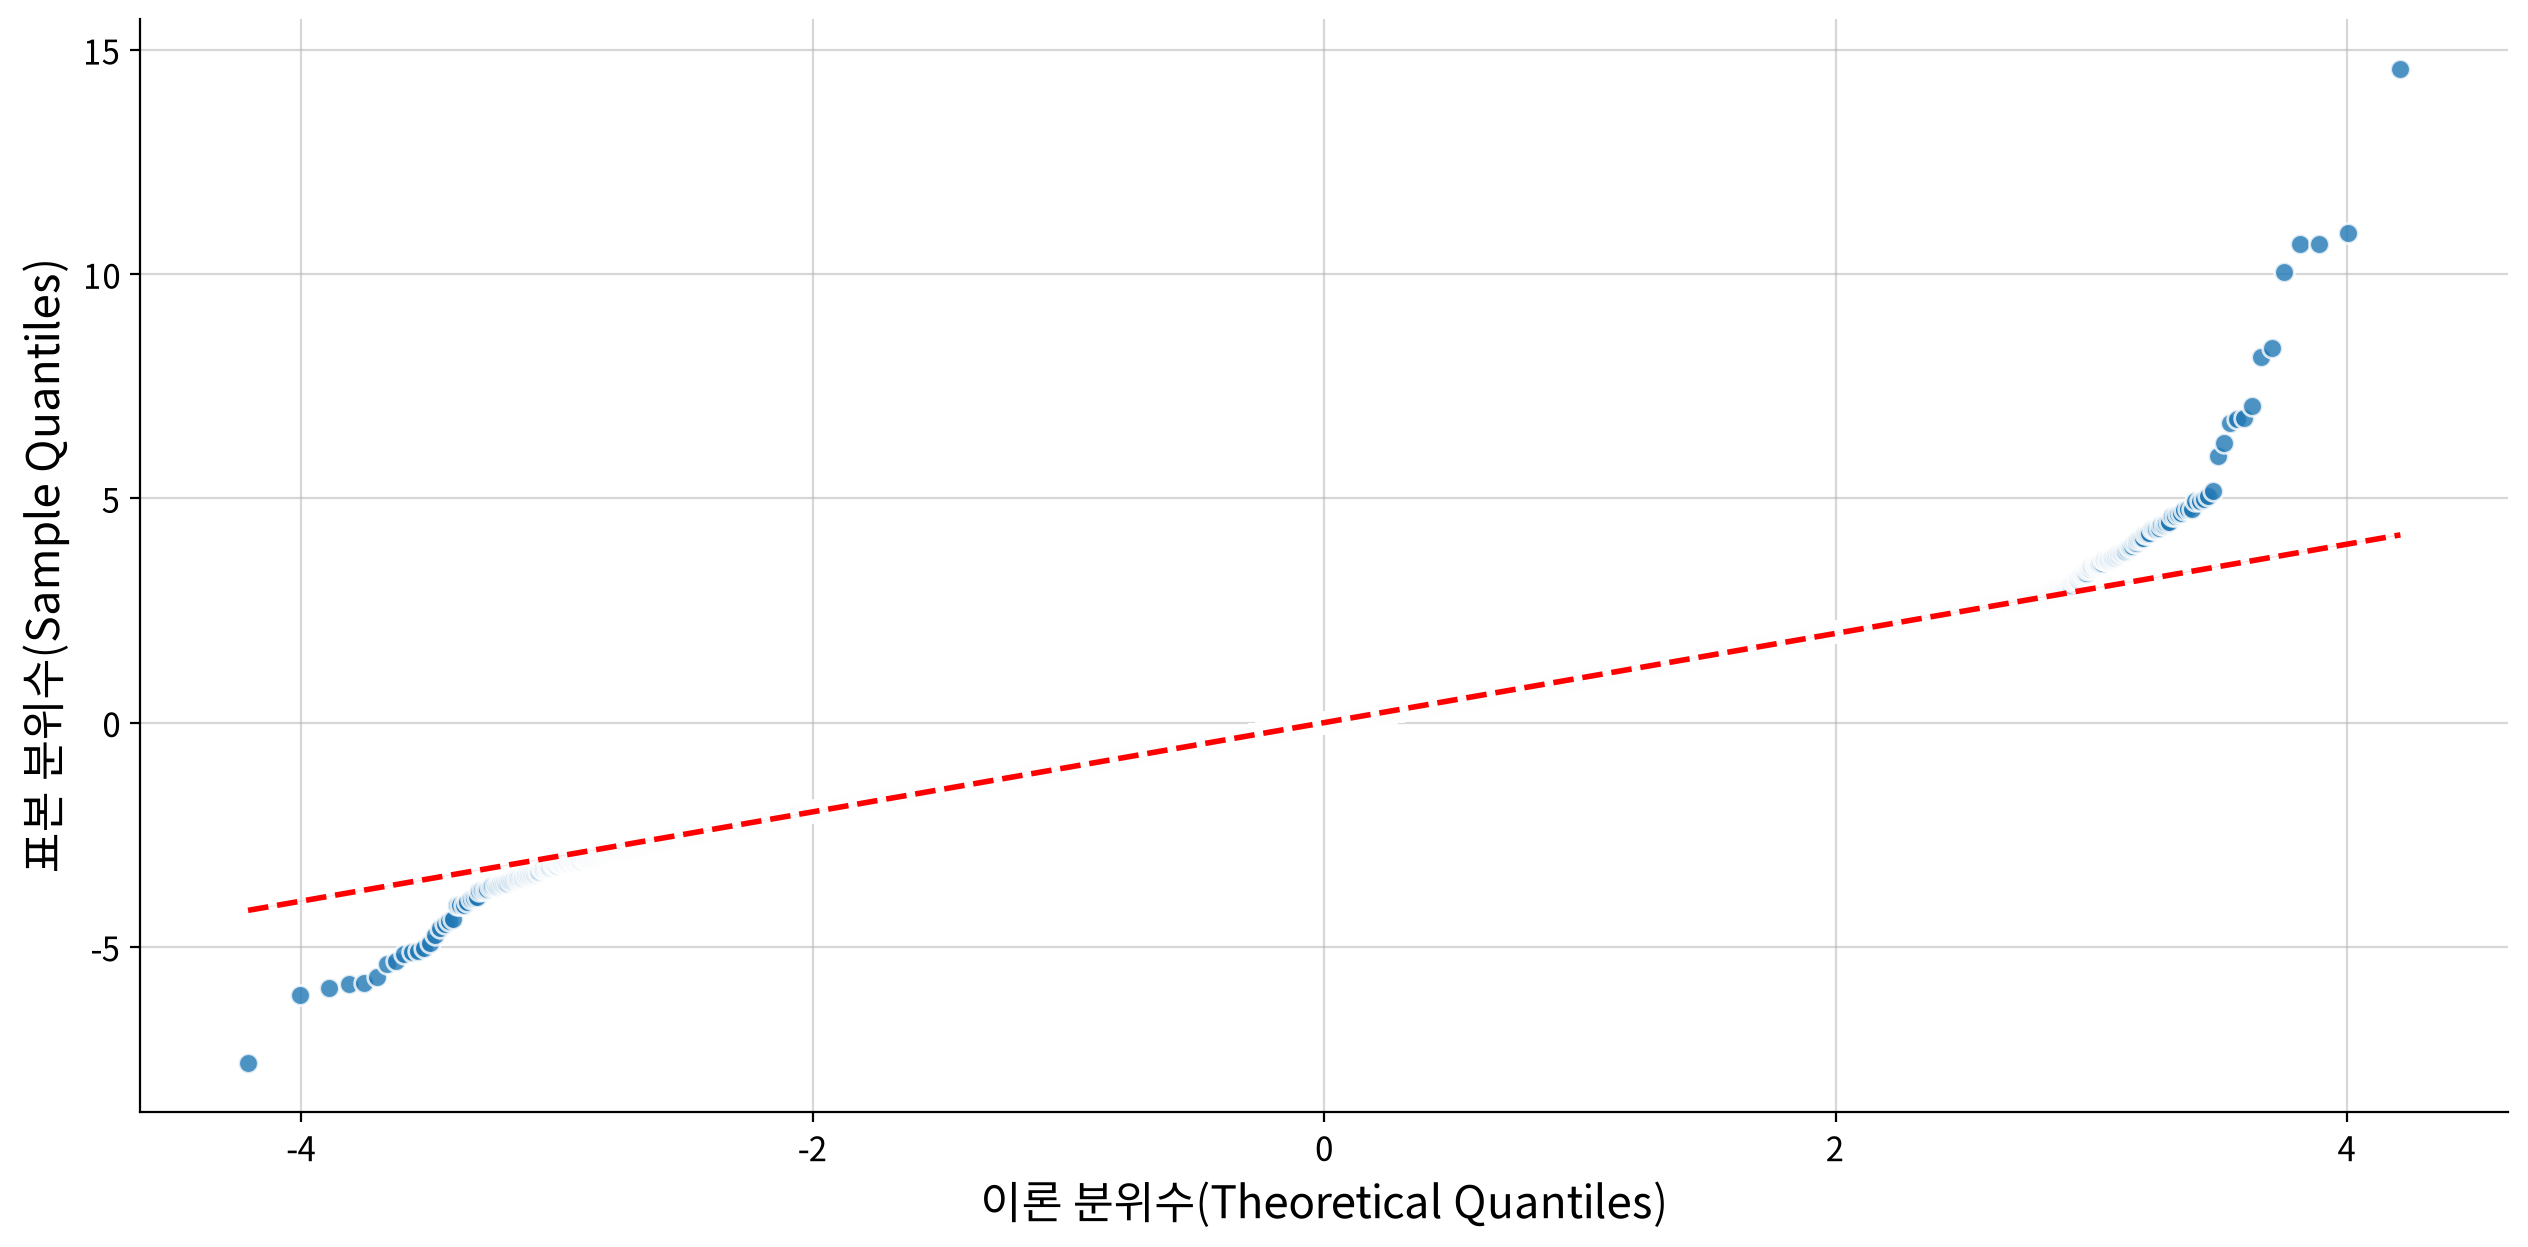

,기대(%),허용범위(%),실제(%),판정
구간,,,,
±1√MSE,68.000,68~68,69.740,위배
±2√MSE,95.000,95~95,95.420,위배
±3√MSE,99.700,100~100,99.600,위배


√MSE = 0.13 · 구간 규칙 판정: 정규성 위배


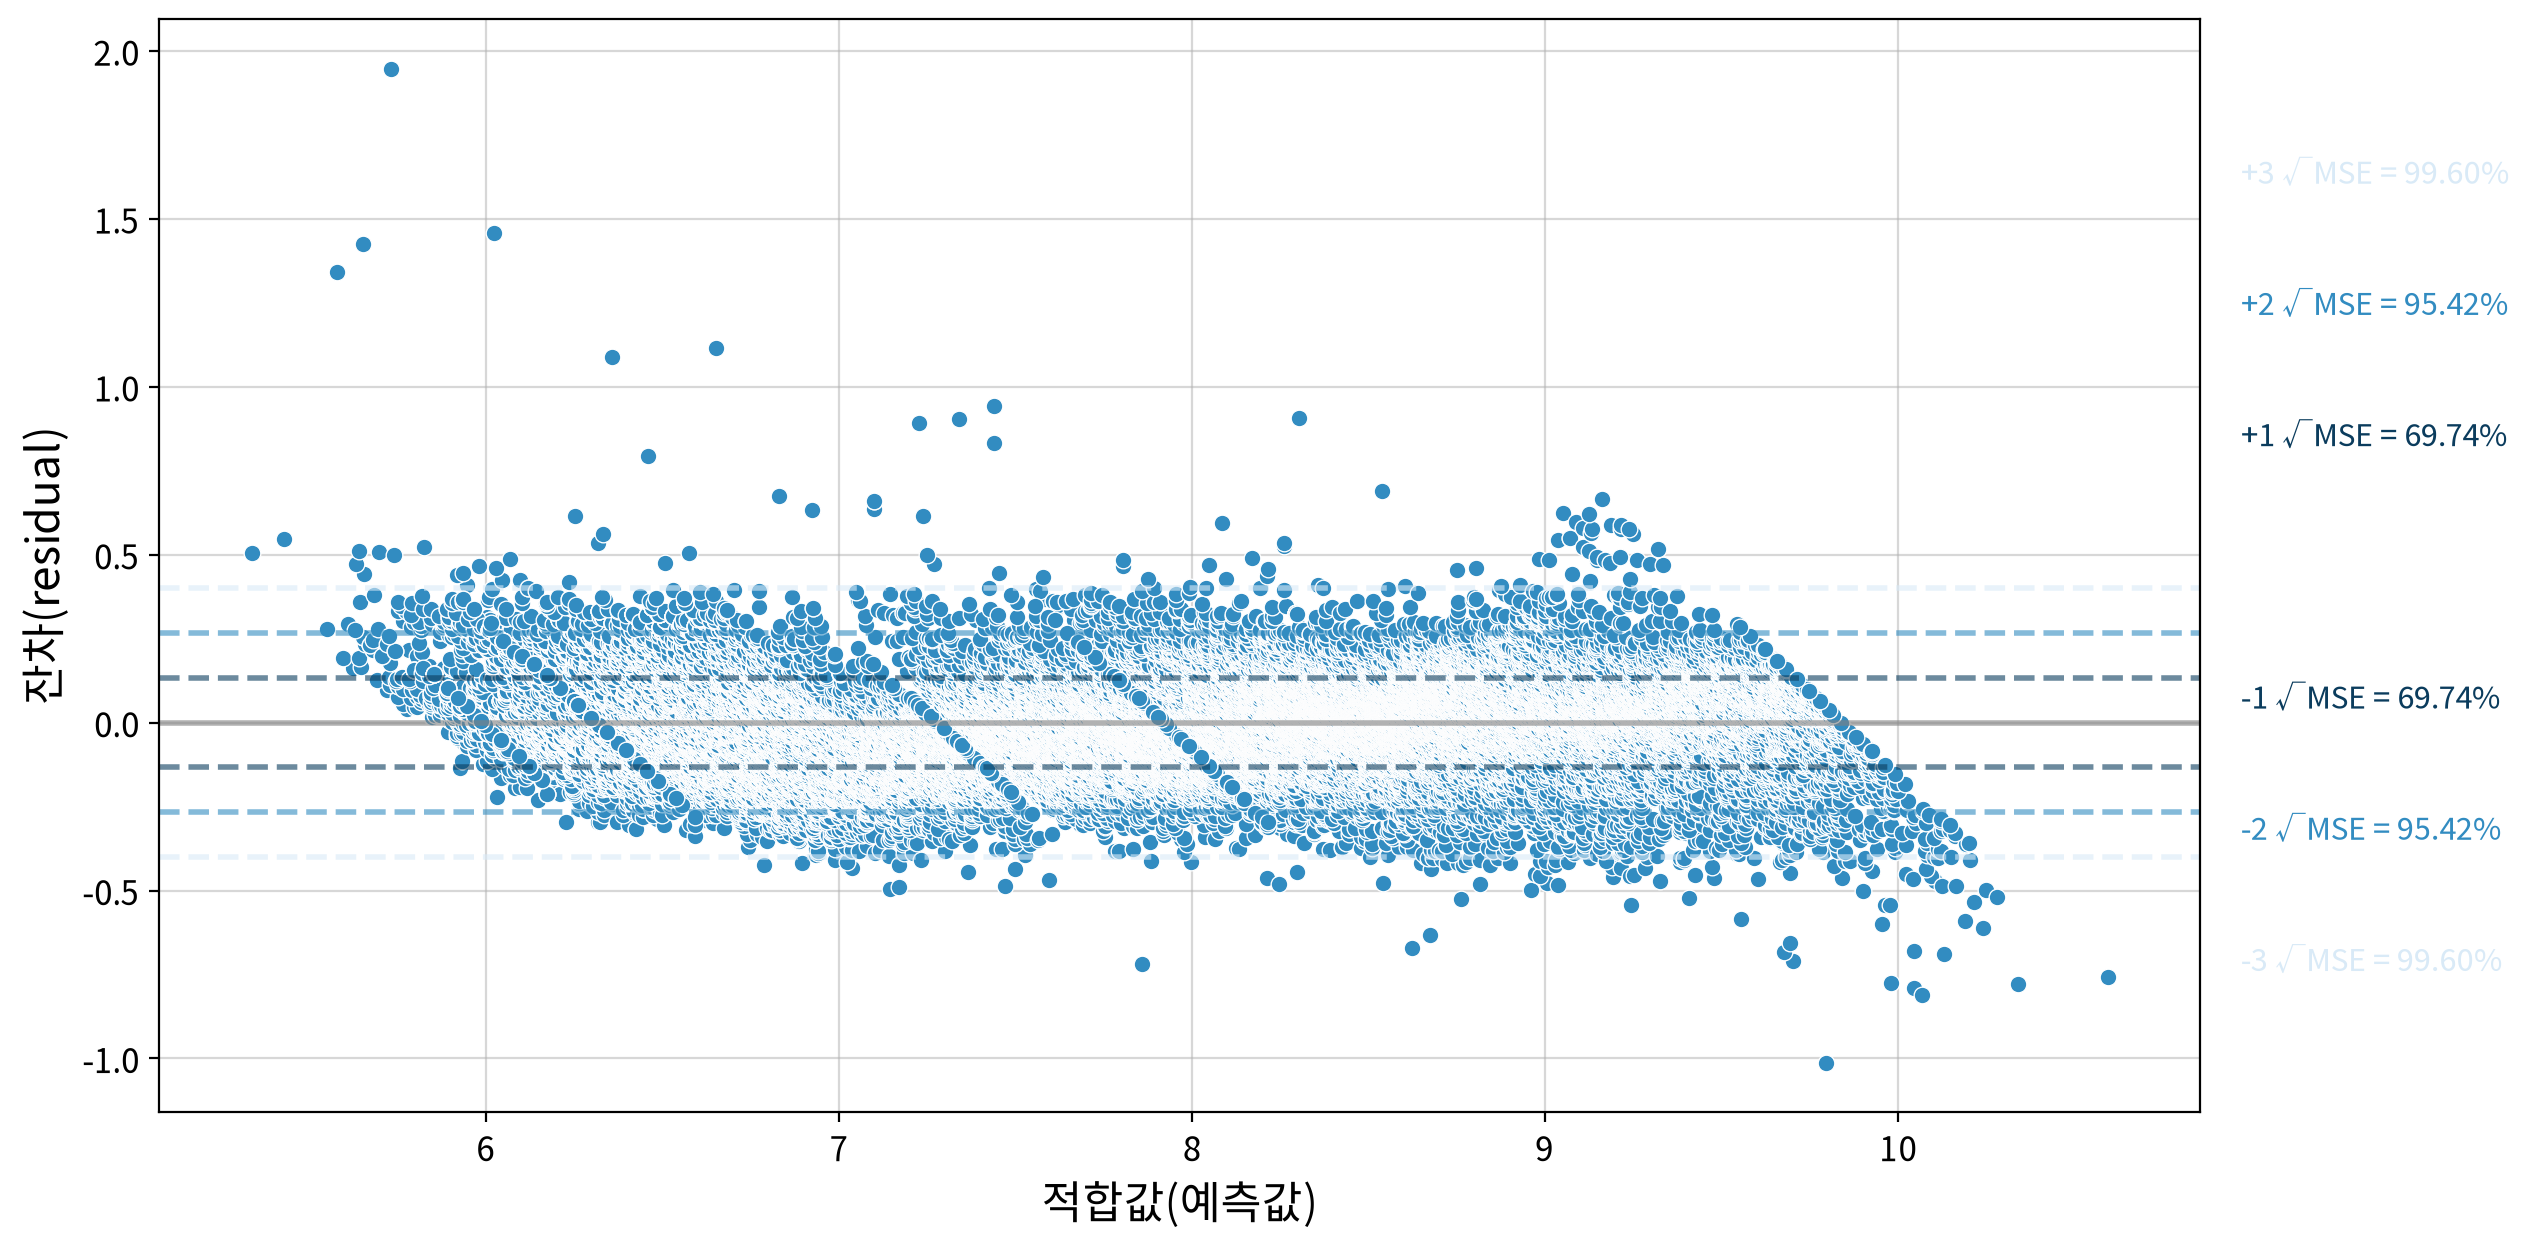

#### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,1336.676,0.000,76.125,0.000,False,대립가설 채택 → 등분산 아님


#### 4) 독립성 검정

,statistic,independence,result
Durbin-Watson,1.253,False,독립성 위반 (양(+)의 자기상관)


In [16]:
my_ols.report_model(final_fit)

#### 💡 인사이트

**모형 요약** — `log1p(price) ~ log(carat) + cut·color·clarity 더미`

- **F(18, 53775) = 169,316.51, p < .001, R² = 0.983** 으로 가격 분산의 98.3%를 설명한다. 18개 변수 모두 유의하다(HC3 기준 p < .001).
- **영향력은 `carat` 이 압도적이다.** 표준화 계수 β = 1.086으로, 2위인 `clarity_5`(β = 0.306)의 3.5배다.
  나머지 17개 더미의 β를 모두 합해도 `carat` 하나에 미치지 못한다.
- **`carat` 은 탄력성**으로 읽는다 — 중량이 1% 늘면 가격은 약 **1.88% 상승**한다.
- **더미는 기준 범주 대비 가격 차이**다(기준: `cut`=Fair, `color`=D, `clarity`=I1).

| 등급 | 계수 해석 | 등급 순서와 일치? |
|---|---|---|
| `cut` | Ideal +17.6% > Premium +15.0% > Very Good +12.5% > Good +8.4% | ✅ |
| `color` | D(기준) > E −5.3% > … > J −40.0% | ✅ |
| `clarity` | IF +204.0% > VVS1 +176% > … > SI2 +53.3% | ✅ |

라벨 인코딩이 알파벳순이라 컬럼명은 `cut_2` 처럼 나오지만, 계수의 크기 순서는 실제 품질 등급 순서와 정확히 일치한다.

**가정 검정 — 4개 모두 위배**

| 가정 | 통계량 | 비고 |
|---|---|---|
| 선형성 | RESET F = 946.49, p < .001 | 로그-로그 모형에도 곡선 관계가 남음 |
| 정규성 | K-S = 0.018, p < .001 | 통계량 자체는 매우 작음 (±1√MSE 구간 69.8% vs 기대 68%) |
| 등분산성 | BP F = 76.05, p < .001 | HC3 로버스트 표준오차로 자동 보정됨 |
| 독립성 | DW = 1.252 | 양(+)의 자기상관 |

n = 53,794의 대표본에서는 미세한 이탈도 검정에서 유의하게 나온다. 정규성은 구간 규칙상 기대값과 1.8%p 차이에 불과해 실질적 문제로 보기 어렵다.

---

**한계점**

- **표본이 시장 전체를 대표하지 않는다.** 특정 시점·유통 경로의 데이터이므로 시세 변동이나 다른 시장에 그대로 적용할 수 없다.
- **선형성 위배가 남아 있다.** 두 변수에 모두 로그를 씌우고도 곡선 관계가 검출되므로, 중량 구간에 따라 가격 반응이 달라질 가능성이 있다.
- **이상치를 IQR 경계값으로 대체했다.** 실제로 존재하는 고가 다이아몬드를 인위적으로 눌러 놓은 것이므로, 극단 구간의 설명력은 낮아진다.
- **등분산 위배로 예측의 정밀도가 일정하지 않다.** 계수의 유의성은 HC3로 보정했지만, 고가 구간일수록 오차가 커지는 문제는 그대로 남는다.
- **독립성 위배(DW = 1.252)는 해석이 불가능하다.** 시계열 데이터가 아닌 횡단면 데이터이므로 독립성의 영향을 받지 않는다.

**개선 방향**

- **`log(carat)` 의 제곱항이나 구간 분할**을 적용해 잔존 곡선 관계를 흡수한다.
- **`carat` 과 등급의 상호작용항**을 검토한다. EDA에서 `clarity` 별 `carat` 기울기가 2.76배 차이 났으므로 근거가 있다.
- **행 순서를 무작위로 섞은 뒤 DW를 다시 확인**해 자기상관이 실재하는지 판별한다.
- **제외했던 `x`·`y`·`z` 를 부피(`x × y × z`) 같은 파생변수로 되살려** 공선성 없이 형태 정보를 활용한다.
- **잔차가 큰 관측치를 따로 추려** 특정 등급·가격대에 치우쳐 있는지 확인한다.